# CCTV Anomaly Detection with a ConvLSTM Autoencoder

This notebook builds a simple anomaly detection system for CCTV footage.

The idea is not to teach the model every possible crime or abnormal event by label.  
Instead, we teach it what **normal video behaviour** looks like.

Then we ask:

- can the model reconstruct a normal clip well?
- does it struggle more when the clip contains unusual motion or behaviour?

If the reconstruction gets worse, the reconstruction error goes up.  
That rising error becomes our anomaly signal.

## What this notebook covers

This notebook explains:

- what a video clip looks like to a machine learning model
- what an autoencoder is
- what ConvLSTM means
- why reconstruction error can help detect anomalies
- how to load CCTV clips from folders
- how to train on normal footage only
- how to test on anomaly footage
- how to save plots and screenshots for GitHub

## Folder structure used in this notebook

```text
cctv-anomaly-detection/
├── data/
│   └── cctv_subset/
│       ├── normal/
│       ├── assault/
│       ├── burglary/
│       ├── fighting/
│       └── shooting/
├── notebooks/
│   └── cctv_anomaly_detection.ipynb
├── outputs/
│   ├── frames/
│   ├── plots/
│   └── videos/
└── requirements.txt

In [1]:

from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.layers import Input, ConvLSTM2D, BatchNormalization, Conv3D
from tensorflow.keras.models import Model

## Step 1: Project paths

A notebook does not automatically know where your dataset is.

So the first thing we do is define the project folders clearly.

We also create output folders if they do not already exist.

### What is `Path`?

`Path` comes from Python's `pathlib` module.

It gives us a safer and cleaner way to work with file and folder paths than writing long text strings by hand.

For example:

- bad habit: `"C:/Users/name/project/data/file.mp4"`
- better habit: `PROJECT_ROOT / "data" / "file.mp4"`

That second form is easier to read and less fragile.

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "cctv subset"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FRAMES_DIR = OUTPUTS_DIR / "frames"
PLOTS_DIR = OUTPUTS_DIR / "plots"
VIDEOS_DIR = OUTPUTS_DIR / "videos"

FRAMES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook current folder:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Does data folder exist?", DATA_DIR.exists())

Notebook current folder: c:\Users\nosai\Downloads\cctv-anomaly-detection\notebooks
Project root: c:\Users\nosai\Downloads\cctv-anomaly-detection
Data folder: c:\Users\nosai\Downloads\cctv-anomaly-detection\data\cctv subset
Does data folder exist? True


## Step 2: List the available videos

Before training any model, check that the files actually exist.

This sounds obvious, but most notebook errors come from bad paths, wrong folder names, empty folders, or file extensions that do not match the code.

### Why this matters

If the model code fails, that is one kind of problem.

If the data loading is broken, then every later result becomes meaningless.

So we check the folder contents first.

In [3]:
def list_videos(folder_path):
    return sorted(folder_path.glob("*.mp4"))

normal_videos = list_videos(DATA_DIR / "normal")
assault_videos = list_videos(DATA_DIR / "assault")
burglary_videos = list_videos(DATA_DIR / "burglary")
fighting_videos = list_videos(DATA_DIR / "fighting")
shooting_videos = list_videos(DATA_DIR / "shooting")

print("Normal videos:", len(normal_videos))
print("Assault videos:", len(assault_videos))
print("Burglary videos:", len(burglary_videos))
print("Fighting videos:", len(fighting_videos))
print("Shooting videos:", len(shooting_videos))

print("\nSample normal files:")
for video in normal_videos[:5]:
    print("-", video.name)

Normal videos: 15
Assault videos: 1
Burglary videos: 1
Fighting videos: 1
Shooting videos: 1

Sample normal files:
- Normal_Videos001_x264.mp4
- Normal_Videos002_x264.mp4
- Normal_Videos004_x264.mp4
- Normal_Videos005_x264.mp4
- Normal_Videos007_x264.mp4


## Step 3: Inspect one sample video

A video is just a sequence of frames.

A frame is just an image.

That means machine learning on video usually starts with reading frames one by one.

### Terms

**Frame count**  
How many images exist inside the video.

**FPS**  
Frames per second.  
If a video has 30 FPS, that means 30 images are shown every second.

**Width and height**  
The size of each frame in pixels.

In [4]:
if len(normal_videos) == 0:
    raise FileNotFoundError("No normal videos found. Check your data path and folder contents.")

sample_video_path = normal_videos[0]
print("Using sample video:", sample_video_path.name)

cap = cv2.VideoCapture(str(sample_video_path))

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.release()

print("Frame count:", frame_count)
print("FPS:", fps)
print("Width:", width)
print("Height:", height)

Using sample video: Normal_Videos001_x264.mp4
Frame count: 544
FPS: 30.0
Width: 320
Height: 240


## Step 4: Extract frames from a video

We do not feed the whole raw video file directly into the model.

We first convert it into a short clip of frames.

### Why resize to 64 × 64?

Smaller images make training easier.

You lose detail, but this is a fair trade:
- less memory use
- faster training
- easier debugging

### Why convert BGR to RGB?

OpenCV reads images in BGR order by default.

Matplotlib and most deep learning pipelines expect RGB order.

If we do not convert:
- colours look wrong
- debugging becomes annoying

### Why divide by 255?

Raw pixel values usually go from 0 to 255.

Neural networks train more easily when values are scaled to a smaller range like 0 to 1.

In [5]:
def extract_frames(video_path, num_frames=16, size=(64, 64)):
    """
    Read a short fixed-length clip from a video.

    Parameters
    ----------
    video_path : Path
        Path to the .mp4 video file.
    num_frames : int
        Number of frames to extract.
    size : tuple
        The target width and height for resizing.

    Returns
    -------
    np.ndarray
        Array of shape (num_frames_found, height, width, 3)
        with pixel values normalised to [0, 1].
    """
    cap = cv2.VideoCapture(str(video_path))
    frames = []

    while len(frames) < num_frames:
        success, frame = cap.read()

        if not success:
            break

        frame = cv2.resize(frame, size)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = frame.astype("float32") / 255.0
        frames.append(frame)

    cap.release()
    return np.array(frames)

In [6]:
sample_frames = extract_frames(sample_video_path, num_frames=16, size=(64, 64))
print("Extracted frame array shape:", sample_frames.shape)

Extracted frame array shape: (16, 64, 64, 3)


## Step 5: Understand the shape of the data

A lot of machine learning confusion comes from tensor shapes.

If the shape makes sense, the code usually makes sense too.

If the shape is wrong, everything breaks.

Suppose the printed shape is:

```python
(16, 64, 64, 3)

This means:

16 frames
each frame has height 64
each frame has width 64
3 colour channels: red, green, blue

That is one short video clip.

Later, when we stack many clips together, the shape becomes:

(number_of_clips, 16, 64, 64, 3)

That first extra dimension is the batch dimension.

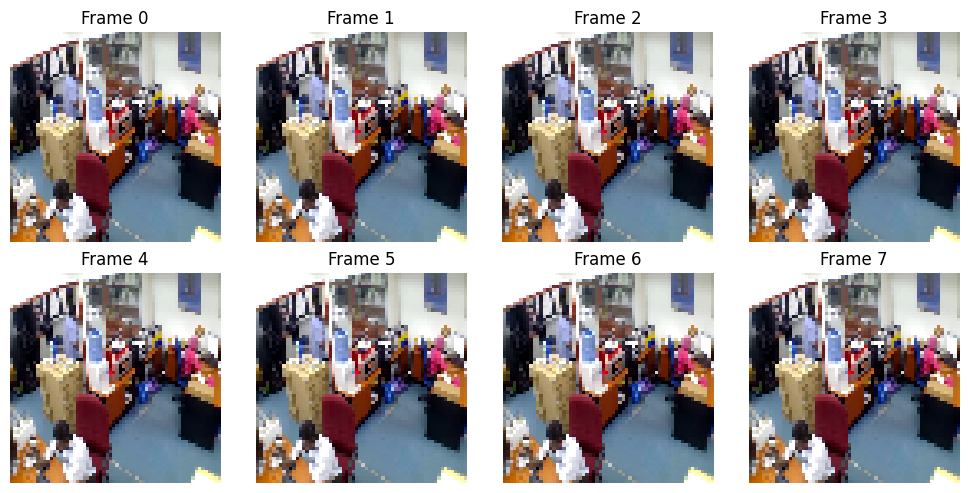

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    if i < len(sample_frames):
        ax.imshow(sample_frames[i])
        ax.set_title(f"Frame {i}")
        ax.axis("off")

plt.tight_layout()
plt.show()

## Step 6: Save one screenshot for proof

A project with only code and no visible result often looks unfinished.

So we save:
- sample frames
- training loss plot
- original vs reconstructed comparison
- anomaly score plot
- flagged anomaly frames

In [8]:
frame_to_save = (sample_frames[0] * 255).astype("uint8")
frame_bgr = cv2.cvtColor(frame_to_save, cv2.COLOR_RGB2BGR)

sample_frame_path = FRAMES_DIR / "normal_sample_frame_0.jpg"
cv2.imwrite(str(sample_frame_path), frame_bgr)

print("Saved sample frame to:", sample_frame_path)

Saved sample frame to: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\normal_sample_frame_0.jpg


## Step 7: Build the training clips from several normal videos

We do not want to train on just one clip.

That would make the model too narrow and too brittle.

So we collect several normal clips.

### Why only normal videos?

This is the heart of anomaly detection by reconstruction.

We want the model to learn:

> "This is what ordinary footage tends to look like."

Then when the model sees something unusual, it often reconstructs it worse.

### Important concept: unsupervised learning

This kind of setup is close to unsupervised or weakly supervised learning.

We are not giving labels like:
- frame 1 = normal
- frame 2 = crime
- frame 3 = assault

We are mostly teaching the model one pattern: normality.

In [9]:
def build_training_clips(video_paths, num_frames=16, size=(64, 64)):
    clips = []

    for video_path in video_paths:
        frames = extract_frames(video_path, num_frames=num_frames, size=size)

        if len(frames) == num_frames:
            clips.append(frames)

    return np.array(clips)

train_clips = build_training_clips(normal_videos[:15], num_frames=16, size=(64, 64))
print("Training clips shape:", train_clips.shape)

Training clips shape: (15, 16, 64, 64, 3)


## Step 8: What is an autoencoder?

An autoencoder is a model that tries to reproduce its own input.

Input goes in.  
The model compresses it into internal features.  
Then it tries to reconstruct the original input.

So the target output is the same as the input.

### Why do this?

Because if the model becomes good at reconstructing one type of data, it may struggle on data that is different.

That struggle shows up as reconstruction error.

### In this project

Input:
- a short normal video clip

Target:
- the same clip again

Loss:
- how far the reconstructed clip is from the original clip

## Step 9: What is ConvLSTM?

This term looks scary, but it is easier if you split it.

### CNN or convolution

A convolution layer is good at looking at image structure:
- edges
- shapes
- textures
- local patterns

That makes it strong for images.

### LSTM

LSTM stands for Long Short-Term Memory.

It is a type of recurrent neural network that tries to remember information across time.

That makes it useful for sequences:
- text
- time series
- video frames

### ConvLSTM

ConvLSTM combines both ideas:
- convolution for spatial patterns inside each frame
- recurrent memory for temporal patterns across frames

That makes it a natural fit for video.

A normal LSTM treats inputs as flat vectors.  
A ConvLSTM keeps the image-like structure alive.

That matters because a video is not just a list of numbers.  
It is moving spatial information across time.

## Step 10: What is Batch Normalization?

Batch Normalization helps stabilise training.

Very roughly, it keeps activations from drifting too wildly during training.

That can help the model:
- train faster
- become more stable
- avoid some ugly learning behaviour

It does not solve everything.  
But it often helps.

## Step 11: What is Conv3D doing at the end?

Our model processes a sequence of frames.

So the output is not just one image.  
It is a whole clip.

`Conv3D` lets us produce an output that still has:
- time
- height
- width
- channels

At the end, we want 3 channels because the input clip is RGB.

In [10]:
def build_autoencoder(input_shape):
    """
    Build a ConvLSTM autoencoder for short video clips.

    input_shape should be:
    (time_steps, height, width, channels)
    """
    inputs = Input(shape=input_shape)

    # First ConvLSTM layer:
    # Learns spatial + temporal patterns from the clip.
    x = ConvLSTM2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        activation="relu"
    )(inputs)
    x = BatchNormalization()(x)

    # Second ConvLSTM layer:
    # Compresses the learned information further.
    x = ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    # Third ConvLSTM layer:
    # Starts decoding toward reconstruction.
    x = ConvLSTM2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    # Final Conv3D reconstruction layer:
    # Output has 3 channels for RGB.
    outputs = Conv3D(
        filters=3,
        kernel_size=(3, 3, 3),
        activation="sigmoid",
        padding="same"
    )(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

model = build_autoencoder((16, 64, 64, 3))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 64, 64, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 16, 64, 64, 64) │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 64, 64, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 16, 64, 64, 32) │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 64, 64, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 16, 64, 64, 64) │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 64, 64, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 16, 64, 64, 3)  │         5,187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,611 (1.88 MB)

 Trainable params: 492,291 (1.88 MB)

 Non-trainable params: 320 (1.25 KB)

## Step 12: What is MSE loss?

MSE means Mean Squared Error.

It measures how far the predicted output is from the target output.

If the model reconstructs the clip well, MSE is low.

If the model reconstructs badly, MSE is higher.

### Why square the error?

Squaring makes larger mistakes hurt more.

That is useful because big reconstruction failures should stand out.

## Step 13: Train the model

We train the model on normal clips only.

That means:
- input = normal clip
- target = same normal clip

### Why validation split?

We keep some training clips aside for validation.

This gives us a rough check on whether the model is learning patterns or just memorising too narrowly.

In [11]:
history = model.fit(
    train_clips,
    train_clips,
    epochs=30,
    batch_size=1,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - loss: 0.0711 - val_loss: 0.0964
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - loss: 0.0482 - val_loss: 0.0873
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 0.0492 - val_loss: 0.0799
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - loss: 0.0506 - val_loss: 0.0729
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - loss: 0.0362 - val_loss: 0.0744
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - loss: 0.0310 - val_loss: 0.0712
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - loss: 0.0263 - val_loss: 0.0705
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - loss: 0.0213 - val_loss: 0.0698
Epoch 9/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - loss: 0.0187 - val_loss: 0.0685
Epoch 10/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - loss: 0.0189 - val_loss: 0.0682
Epoch 11/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 0.0186 - val_loss: 0.0685
Epoch 12/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - loss: 0.0159 - val_lo

## Step 14: Plot the training loss

The loss plot tells us whether the model is learning at all.

If both training and validation loss go down, that is a decent sign.

If loss stays flat or behaves badly, the model may not be learning useful reconstruction.

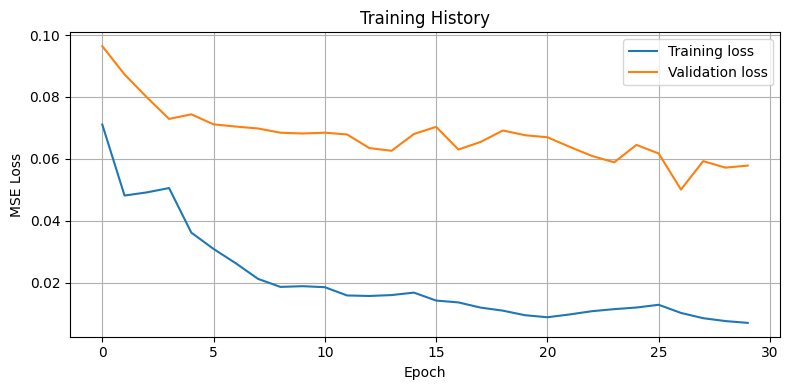

Saved training loss plot to: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\plots\training_loss.png


In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = PLOTS_DIR / "training_loss.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()

print("Saved training loss plot to:", loss_plot_path)

## Step 15: Reconstruct a normal clip

Now we take one normal clip and ask the model to reconstruct it.

This gives us two things:
- a visual comparison
- a numerical reconstruction error

If the model learned normal patterns, the reconstruction should at least vaguely resemble the original clip, even if it looks blurry.

In [13]:
normal_test_clip = train_clips[0:1]
reconstructed_normal = model.predict(normal_test_clip)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [14]:
print("train_clips shape:", train_clips.shape)
print("train_clips min:", train_clips.min())
print("train_clips max:", train_clips.max())

print("reconstructed_normal min:", reconstructed_normal.min())
print("reconstructed_normal max:", reconstructed_normal.max())
print("reconstructed_normal mean:", reconstructed_normal.mean())

normal_mse = np.mean((normal_test_clip[0] - reconstructed_normal[0]) ** 2, axis=(1, 2, 3))
print("Normal frame MSE values:", normal_mse)
print("Mean normal MSE:", normal_mse.mean())

train_clips shape: (15, 16, 64, 64, 3)
train_clips min: 0.0
train_clips max: 1.0
reconstructed_normal min: 0.21032093
reconstructed_normal max: 0.78558254
reconstructed_normal mean: 0.44354546
Normal frame MSE values: [0.07464849 0.08960154 0.08162305 0.07647312 0.07315393 0.07069702
 0.06871071 0.06695301 0.06529042 0.06371852 0.06227467 0.0611528
 0.06014001 0.05935055 0.05871766 0.06370905]
Mean normal MSE: 0.06851341


## Step 16: Visualise original vs reconstructed frames

Do not trust only the loss.

Always look at the images.

A model can reduce loss a bit and still reconstruct in a useless way.

So we compare several frames, not just frame 0.

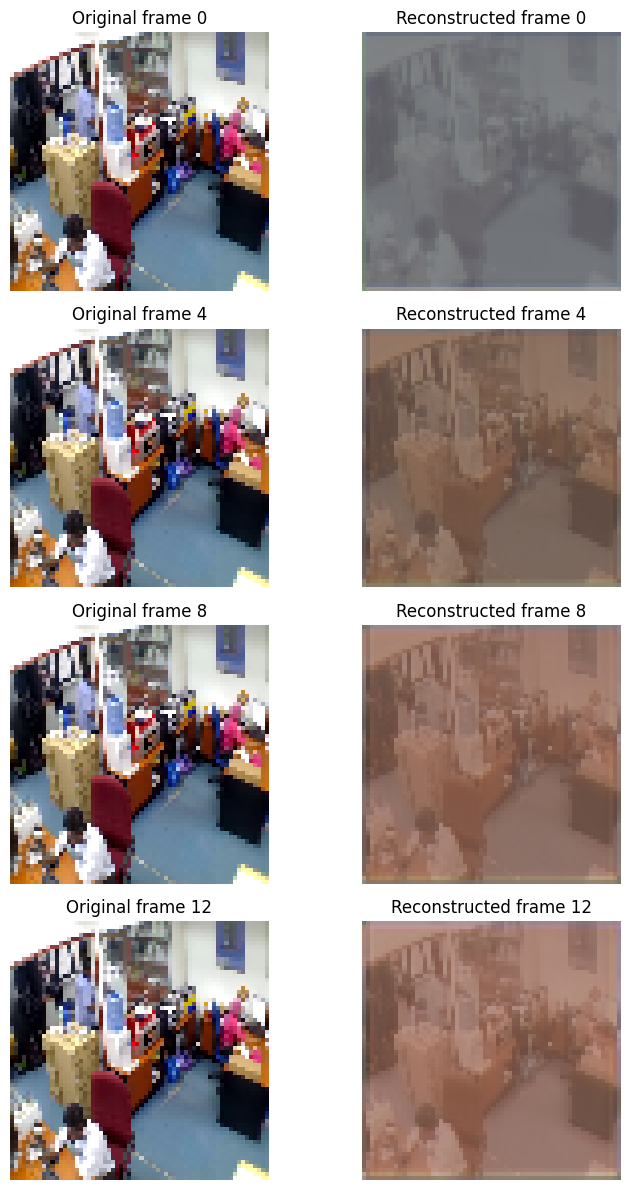

Saved comparison image to: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\normal_original_vs_reconstructed_multi.png


In [15]:
frame_indices = [0, 4, 8, 12]

fig, axes = plt.subplots(len(frame_indices), 2, figsize=(8, 12))

for row, idx in enumerate(frame_indices):
    axes[row, 0].imshow(normal_test_clip[0][idx])
    axes[row, 0].set_title(f"Original frame {idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(reconstructed_normal[0][idx])
    axes[row, 1].set_title(f"Reconstructed frame {idx}")
    axes[row, 1].axis("off")

plt.tight_layout()

comparison_path = FRAMES_DIR / "normal_original_vs_reconstructed_multi.png"
plt.savefig(comparison_path, dpi=150)
plt.show()

print("Saved comparison image to:", comparison_path)

## Step 17: Build a threshold from normal reconstruction error

We need some way to decide when an error is "too high".

A lazy way is to guess a fixed threshold.

A slightly better way is:
- measure the reconstruction errors on normal clips
- compute their average
- add some margin using the standard deviation

That gives us a rough threshold based on the training behaviour.

This is still not perfect.  
But it is more honest than inventing a random number.

In [16]:
train_reconstructions = model.predict(train_clips)

all_normal_errors = np.mean((train_clips - train_reconstructions) ** 2, axis=(2, 3, 4))
flattened_normal_errors = all_normal_errors.flatten()

threshold = flattened_normal_errors.mean() + 2 * flattened_normal_errors.std()

print("Mean normal reconstruction error:", flattened_normal_errors.mean())
print("Std normal reconstruction error:", flattened_normal_errors.std())
print("Estimated anomaly threshold:", threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Mean normal reconstruction error: 0.057103105
Std normal reconstruction error: 0.02190481
Estimated anomaly threshold: 0.10091272


## Step 18: Test on an anomaly clip

Now we test the model on footage from another folder, such as assault.

We still use the same reconstruction idea.

If the anomaly clip differs enough from the learned normal patterns, the model should reconstruct it worse.

That should push the error upward.

In [17]:
if len(assault_videos) == 0:
    raise FileNotFoundError("No assault videos found. Add at least one .mp4 file to the assault folder.")

anomaly_video_path = assault_videos[0]
print("Testing anomaly video:", anomaly_video_path.name)

anomaly_clip = extract_frames(anomaly_video_path, num_frames=16, size=(64, 64))

if len(anomaly_clip) != 16:
    raise ValueError("The anomaly clip did not return 16 frames. Try another video.")

anomaly_clip = np.expand_dims(anomaly_clip, axis=0)
reconstructed_anomaly = model.predict(anomaly_clip)

anomaly_mse = np.mean((anomaly_clip[0] - reconstructed_anomaly[0]) ** 2, axis=(1, 2, 3))
anomaly_flags = anomaly_mse > threshold

print("Anomaly frame errors:", anomaly_mse)
print("Flagged frames:", anomaly_flags)

Testing anomaly video: Assault001_x264.mp4
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Anomaly frame errors: [0.14537671 0.08138544 0.08450089 0.09166881 0.0978603  0.10337111
 0.10783216 0.11153034 0.11446917 0.11640048 0.11773783 0.11932308
 0.12066347 0.12147752 0.12177044 0.12083527]
Flagged frames: [ True False False False False  True  True  True  True  True  True  True
  True  True  True  True]


## Step 19: Plot anomaly scores

This is one of the most important outputs in the whole project.

Each point shows the reconstruction error for one frame.

The red threshold line gives us a simple rule:
- below line = likely normal
- above line = suspicious

That does not mean every flagged frame is truly abnormal.  
It only means the model struggled more there.

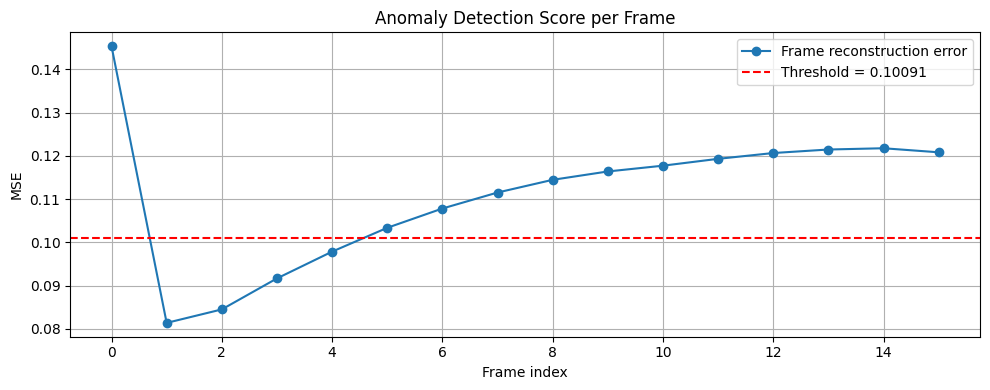

Saved anomaly score plot to: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\plots\assault_anomaly_scores.png


In [18]:
plt.figure(figsize=(10, 4))
plt.plot(anomaly_mse, marker="o", label="Frame reconstruction error")
plt.axhline(y=threshold, color="red", linestyle="--", label=f"Threshold = {threshold:.5f}")
plt.title("Anomaly Detection Score per Frame")
plt.xlabel("Frame index")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()

anomaly_plot_path = PLOTS_DIR / "assault_anomaly_scores.png"
plt.savefig(anomaly_plot_path, dpi=150)
plt.show()

print("Saved anomaly score plot to:", anomaly_plot_path)

## Step 20: Save flagged frames

If a frame crosses the threshold, save it.

This gives you visual proof for:
- GitHub README
- debugging
- project presentation
- report screenshots

A project becomes much easier to explain when the outputs are saved as actual files.

In [19]:
for i, is_anomaly in enumerate(anomaly_flags):
    if is_anomaly:
        frame_rgb = (anomaly_clip[0][i] * 255).astype("uint8")
        frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
        out_path = FRAMES_DIR / f"assault_flagged_frame_{i}.jpg"
        cv2.imwrite(str(out_path), frame_bgr)
        print("Saved:", out_path)

Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_0.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_5.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_6.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_7.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_8.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_9.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_10.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_11.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_12.jpg
Saved: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_flagged_frame_13.jpg
Saved: c:\Users\

## Step 21: Compare anomaly frames and reconstructed versions

Looking at the flagged frame alone is not enough.

We should also look at how the model reconstructed that same frame.

If the original frame contains motion or structure the model did not learn well, the reconstructed frame often looks more distorted or oversmoothed.

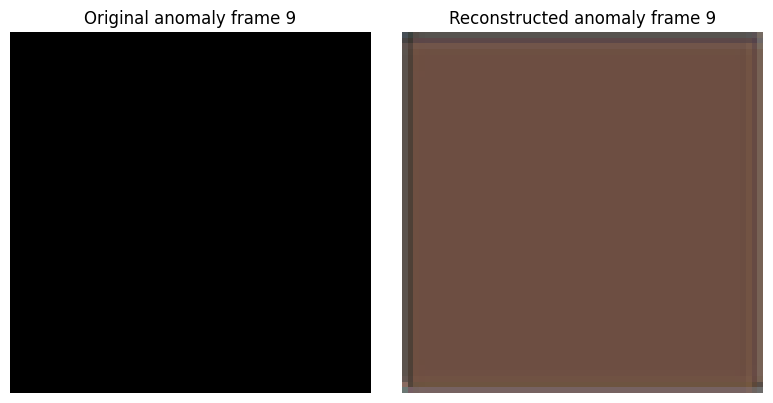

Saved anomaly comparison to: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames\assault_original_vs_reconstructed_frame_9.png


In [27]:
flagged_indices = [i for i, flag in enumerate(anomaly_flags) if flag]

if len(flagged_indices) > 0:
    idx = flagged_indices[5]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(anomaly_clip[0][idx])
    axes[0].set_title(f"Original anomaly frame {idx}")
    axes[0].axis("off")

    axes[1].imshow(reconstructed_anomaly[0][idx])
    axes[1].set_title(f"Reconstructed anomaly frame {idx}")
    axes[1].axis("off")

    plt.tight_layout()

    anomaly_comparison_path = FRAMES_DIR / f"assault_original_vs_reconstructed_frame_{idx}.png"
    plt.savefig(anomaly_comparison_path, dpi=150)
    plt.show()

    print("Saved anomaly comparison to:", anomaly_comparison_path)
else:
    print("No frames crossed the threshold in this clip.")

## Step 22: What did we actually build?

We built a reconstruction-based anomaly detector.

The pipeline is:

1. read normal video clips
2. convert them into frame tensors
3. train a ConvLSTM autoencoder to reconstruct them
4. compute reconstruction error on new clips
5. flag frames where the error becomes unusually high

### Why this can work

Because the model becomes better at reproducing patterns it has seen often.

Normal behaviour becomes easier to reconstruct.  
Unexpected behaviour often becomes harder.

### Why this can fail

Many things besides a true anomaly can raise reconstruction error:

- sudden lighting changes
- camera motion
- blur
- compression noise
- poor training clips
- too few normal examples
- a weak threshold choice


## Step 23: Terms recap

### Autoencoder
A model that tries to reconstruct its own input.

### Reconstruction error
The difference between the original input and the reconstructed output.

### MSE
Mean Squared Error. A common way to measure reconstruction error.

### Convolution
A way to detect local visual patterns such as edges and textures in images.

### LSTM
A neural network unit designed for sequence data and temporal memory.

### ConvLSTM
A video-friendly sequence layer that keeps spatial image structure while modelling time.

### Threshold
A cutoff value used to decide whether an error is unusually high.

### Unsupervised anomaly detection
A setup where the model learns ordinary patterns without explicit anomaly labels, then flags deviations.

## Step 24: Limitations of this notebook

This notebook is useful for learning, but it has hard limits:

- tiny subset of the dataset
- small number of normal clips
- no formal evaluation metric like AUC or ROC
- no ground-truth anomaly intervals
- simple thresholding
- no temporal smoothing across predictions
- no stronger encoder backbone

That is fine for a first clean project.

## Step 25: Good next improvements

If you want to improve the project later, try:

- train on more normal clips
- sample clips from different parts of each video, not only the first 16 frames
- use a sliding window across the video
- evaluate on more anomaly categories
- compare normal error distribution vs anomaly error distribution
- try prediction-based models instead of reconstruction
- add GIFs or screenshots to the README

In [21]:
print("Notebook finished.")
print("Saved outputs folder:", OUTPUTS_DIR)
print("Saved frame images folder:", FRAMES_DIR)
print("Saved plots folder:", PLOTS_DIR)

Notebook finished.
Saved outputs folder: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs
Saved frame images folder: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\frames
Saved plots folder: c:\Users\nosai\Downloads\cctv-anomaly-detection\outputs\plots
